# FINAL PROJECT: Our 10-Model Sentiment Stacking Ensemble
## Goal: Solving the "Domain Shift" with a Memory-Safe Architecture

**Team Integration:**
- **Ivy:** Fast SVM (LinearSVC) & Bi-LSTM
- **Larry:** Naive Bayes & TextCNN
- **Ritah:** Logistic Regression & LSTM
- **Julianah:** Random Forest & Bi-GRU
- **David:** DistilBERT (The heavyweight model!)
- **Meta-Learner:** XGBoost (Combining all 10 models)

---

## PART 1: SETUP & HARD GPU LIMIT

In [1]:
import os, re, string, random, zipfile, urllib.request, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout, SpatialDropout1D, Bidirectional,
    Input, Concatenate, GlobalAveragePooling1D, GlobalMaxPooling1D, Conv1D
)
from tensorflow.keras.callbacks import EarlyStopping

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import xgboost as xgb

# --- THE ULTIMATE OOM FIX: HARD MEMORY LIMIT ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Limit TensorFlow to 4GB of VRAM, leaving 10GB for David's BERT
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)])
        print("Hard Limit Set: TF is limited to 4GB. BERT now has plenty of room!")
    except RuntimeError as e:
        print(e)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete! We are using: {DEVICE}")

2026-05-26 04:45:57.335832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779770757.548901      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779770757.612995      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779770758.093090      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779770758.093128      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779770758.093131      57 computation_placer.cc:177] computation placer alr

Hard Limit Set: TF is limited to 4GB. BERT now has plenty of room!
Setup complete! We are using: cuda


## PART 2: LOADING DATA & CLEANING

In [2]:
def extract_meta_features(df):
    df = df.copy()
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
    df['is_all_caps'] = df['text'].apply(lambda x: 1 if str(x).isupper() and len(str(x)) > 5 else 0)
    df['char_cnt'] = df['text'].apply(lambda x: len(str(x)))
    df['word_cnt'] = df['text'].apply(lambda x: len(str(x).split()))
    platforms = r'github|slack|coursera|udemy|paystack|railway|netlify|heroku|mtn|airtel|gmail|whatsapp'
    alerts = r'invoice|billing|terminate|security|alert|reminder|approved|successful|failed|payment'
    df['has_platform_mention'] = df['text'].apply(lambda x: 1 if re.search(platforms, str(x).lower()) else 0)
    df['has_service_alert'] = df['text'].apply(lambda x: 1 if re.search(alerts, str(x).lower()) else 0)
    return df

def surgical_cleaner(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else "notification"

print("Loading and combining datasets...")
train_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/processed_training_dataset.csv').dropna()
val_df = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/processed_validation_datset.csv').dropna()
train_df = pd.concat([train_df, val_df]).reset_index(drop=True)
test_df  = pd.read_csv('/kaggle/input/datasets/tagooledavid256/finalbook/student_test_dataset.csv').dropna()

train_df = extract_meta_features(train_df)
test_df  = extract_meta_features(test_df)
train_df['clean'] = train_df['text'].apply(surgical_cleaner)
test_df['clean']  = test_df['text'].apply(surgical_cleaner)

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label']  = test_df['sentiment'].map(label_map)
y_train, y_test = train_df['label'].values, test_df['label'].values

Loading and combining datasets...


## PART 3: PREPARING THE STACKING LOOP

In [3]:
print("Scaling metadata features...")
meta_cols = ['exclamation_count', 'question_count', 'is_all_caps', 'char_cnt', 'word_cnt', 'has_platform_mention', 'has_service_alert']
scaler = StandardScaler()
X_train_meta = scaler.fit_transform(train_df[meta_cols])
X_test_meta  = scaler.transform(test_df[meta_cols])

print("Tokenizing for deep learning...")
VOCAB_SIZE, MAX_LEN = 20000, 150
dl_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
dl_tokenizer.fit_on_texts(train_df['clean'])

print("Downloading GloVe...")
glove_path = 'glove.6B.100d.txt'
if not os.path.exists(glove_path):
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z: z.extract(glove_path)
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        v = line.split()
        embeddings_index[v[0]] = np.asarray(v[1:], dtype='float32')

embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in dl_tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word)
        if vec is not None: embedding_matrix[i] = vec

Scaling metadata features...
Tokenizing for deep learning...


## PART 4: DAVID'S BERT HELPER

In [4]:
def train_distilbert(train_txt, train_lbl):
    from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    train_enc = tokenizer(train_txt.tolist(), truncation=True, padding=True, max_length=128)
    class SentiDS(torch.utils.data.Dataset):
        def __init__(self, enc, lbl):
            self.enc = enc
            self.lbl = lbl
        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(self.lbl[idx])
            return item
        def __len__(self): return len(self.lbl)
    
    model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3).to(DEVICE)
    # --- Memory Optimized Arguments ---
    args = TrainingArguments(
        output_dir='results', 
        num_train_epochs=1, 
        per_device_train_batch_size=8, 
        gradient_accumulation_steps=4, # Simulates batch size 32 with memory of 8
        dataloader_pin_memory=False, # Prevents Kaggle memory fragmentation
        fp16=True, 
        disable_tqdm=True
    )
    trainer = Trainer(model=model, args=args, train_dataset=SentiDS(train_enc, train_lbl))
    trainer.train()
    return model, tokenizer

## PART 5: THE BIG STACKING LOOP (OOM-RESISTANT)

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
train_predictions = np.zeros((len(train_df), 30))
test_predictions  = np.zeros((len(test_df), 30))
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: cw[i] for i in range(3)}

print("Starting the 5-fold stacking loop...")
for fold, (t_idx, v_idx) in enumerate(skf.split(train_df['clean'], y_train)):
    print(f"\n--- FOLD {fold+1} ---")
    
    # Localized Callbacks to reset cleanly every fold
    es_cnn = EarlyStopping(patience=2, restore_best_weights=True)
    es_lstm = EarlyStopping(patience=2, restore_best_weights=True)
    es_bilstm = EarlyStopping(patience=2, restore_best_weights=True)
    es_bigru = EarlyStopping(patience=2, restore_best_weights=True)

    vec = TfidfVectorizer(max_features=5000)
    vec.fit(train_df['clean'].iloc[t_idx])
    X_t_tfidf = vec.transform(train_df['clean'].iloc[t_idx])
    X_v_tfidf = vec.transform(train_df['clean'].iloc[v_idx])
    X_test_tfidf_f = vec.transform(test_df['clean'])
    
    print("Training Classical Models (NB, LogReg, SVM)...")
    # 1. NB
    nb = MultinomialNB().fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 0:3] = nb.predict_proba(X_v_tfidf)
    test_predictions[:, 0:3] += nb.predict_proba(X_test_tfidf_f) / 5
    del nb; print("NB Done!")
    # 2. LogReg
    lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 3:6] = lr.predict_proba(X_v_tfidf)
    test_predictions[:, 3:6] += lr.predict_proba(X_test_tfidf_f) / 5
    del lr; print("LogReg Done!")
    # 3. SVM
    svm = CalibratedClassifierCV(LinearSVC(class_weight='balanced'), cv=3).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 6:9] = svm.predict_proba(X_v_tfidf)
    test_predictions[:, 6:9] += svm.predict_proba(X_test_tfidf_f) / 5
    del svm; print("SVM Done!")
    
    print("Training Tree & MLP Models...")
    # 4. RF
    rf = RandomForestClassifier(n_estimators=150, max_depth=15, class_weight='balanced', n_jobs=-1).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 9:12] = rf.predict_proba(X_v_tfidf)
    test_predictions[:, 9:12] += rf.predict_proba(X_test_tfidf_f) / 5
    del rf; print("RF Done!")
    # 5. MLP
    mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300).fit(X_t_tfidf, y_train[t_idx])
    train_predictions[v_idx, 12:15] = mlp.predict_proba(X_v_tfidf)
    test_predictions[:, 12:15] += mlp.predict_proba(X_test_tfidf_f) / 5
    del mlp; print("MLP Done!")
    
    # --- Deep Learning (TensorFlow) ---
    X_t_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[t_idx]), maxlen=MAX_LEN)
    X_v_seq = pad_sequences(dl_tokenizer.texts_to_sequences(train_df['clean'].iloc[v_idx]), maxlen=MAX_LEN)
    X_test_seq_f = pad_sequences(dl_tokenizer.texts_to_sequences(test_df['clean']), maxlen=MAX_LEN)
    
    def train_dl(m_obj, name, col, es_obj):
        m_obj.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
        m_obj.fit(X_t_seq, y_train[t_idx], epochs=10, batch_size=64, verbose=0, 
                  callbacks=[es_obj], class_weight=cw_dict)
        train_predictions[v_idx, col:col+3] = m_obj.predict(X_v_seq)
        test_predictions[:, col:col+3] += m_obj.predict(X_test_seq_f) / 5
        del m_obj; tf.keras.backend.clear_session(); gc.collect()
        print(f"{name} Done!")

    print("Training Deep Learning Block...")
    # 6. CNN
    inp = Input(shape=(MAX_LEN,)); x = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(0.3)(x); x = Conv1D(128, 5, activation='relu')(x)
    train_dl(Model(inputs=inp, outputs=Dense(3, activation='softmax')(GlobalMaxPooling1D()(x))), "CNN", 15, es_cnn)
    
    # 7. LSTM
    inp = Input(shape=(MAX_LEN,)); x = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(0.3)(x)
    train_dl(Model(inputs=inp, outputs=Dense(3, activation='softmax')(LSTM(128)(x))), "LSTM", 18, es_lstm)
    
    # 8. BiLSTM
    inp = Input(shape=(MAX_LEN,)); x = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(0.3)(x)
    train_dl(Model(inputs=inp, outputs=Dense(3, activation='softmax')(Bidirectional(LSTM(64))(x))), "Bi-LSTM", 21, es_bilstm)

    # 9. BiGRU
    inp = Input(shape=(MAX_LEN,)); x = Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(0.3)(x)
    train_dl(Model(inputs=inp, outputs=Dense(3, activation='softmax')(Bidirectional(GRU(64))(x))), "Bi-GRU", 24, es_bigru)
    
    print("Training David's DistilBERT model... (takes longest!)")
    # Final memory clear before BERT
    tf.keras.backend.clear_session(); gc.collect(); torch.cuda.empty_cache()
    
    bert_m, bert_t = train_distilbert(train_df['clean'].iloc[t_idx], y_train[t_idx])
    bert_m.eval()
    with torch.no_grad():
        def get_bert_p(txt_list):
            all_p = []
            # Mini-Batch inference (size 32) to prevent OOM spikes
            for i in range(0, len(txt_list), 32):
                batch = txt_list[i:i+32]
                enc = bert_t(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
                out = bert_m(**enc).logits
                all_p.append(torch.softmax(out, dim=-1).cpu().numpy())
            return np.vstack(all_p)
        
        train_predictions[v_idx, 27:30] = get_bert_p(train_df['clean'].iloc[v_idx].tolist())
        test_predictions[:, 27:30] += get_bert_p(test_df['clean'].tolist()) / 5
    
    del bert_m; torch.cuda.empty_cache(); gc.collect()
    print("Fold Done & Full GPU Cleaned!")

print("All 5 folds complete!")

Starting the 5-fold stacking loop...

--- FOLD 1 ---
Training Classical Models (NB, LogReg, SVM)...
NB Done!
LogReg Done!
SVM Done!
Training Tree & MLP Models...
RF Done!
MLP Done!
Training Deep Learning Block...


I0000 00:00:1779771173.544779      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4096 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779771173.551003      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779771176.344633     151 service.cc:152] XLA service 0x7c9384006b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779771176.344670     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779771176.344674     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779771176.602279     151 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779771178.962194     151 device_compiler.h:188] Compiled cluste

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
CNN Done!
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
LSTM Done!
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Bi-LSTM Done!
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Bi-GRU Done!
Training David's DistilBERT model... (takes longest!)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '5.487', 'grad_norm': '46.1', 'learning_rate': '2.026e-05', 'epoch': '0.5963'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '447.6', 'train_samples_per_second': '119.9', 'train_steps_per_second': '1.874', 'train_loss': '5.001', 'epoch': '1'}
Fold Done & Full GPU Cleaned!
All 5 folds complete!


## PART 6: FINAL MODEL & REPORT

Stacking Matrix Shape: (67080, 37) — 30 model predictions + 7 metadata features

  OUR FINAL 10-MODEL STACKING ENSEMBLE REPORT
              precision    recall  f1-score   support

    Negative       0.85      0.77      0.81        53
     Neutral       0.67      0.85      0.75        60
    Positive       0.85      0.70      0.77        64

    accuracy                           0.77       177
   macro avg       0.79      0.78      0.78       177
weighted avg       0.79      0.77      0.78       177



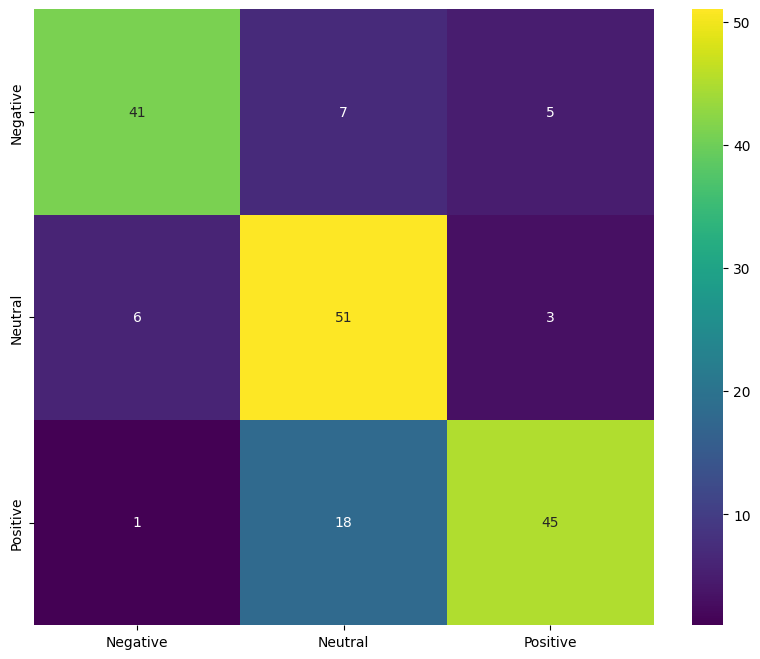

In [6]:
X_stack_train = np.hstack([train_predictions, X_train_meta])
X_stack_test  = np.hstack([test_predictions,  X_test_meta])
print(f"Stacking Matrix Shape: {X_stack_train.shape} — 30 model predictions + 7 metadata features")

final_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, objective='multi:softprob')
final_model.fit(X_stack_train, y_train)

y_final = final_model.predict(X_stack_test)
print("\n" + "="*60)
print("  OUR FINAL 10-MODEL STACKING ENSEMBLE REPORT")
print("="*60)
print(classification_report(y_test, y_final, target_names=label_map.keys()))

cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.show()